In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import torch.utils.data as data
import os
from torch.cuda.amp import autocast, GradScaler
from torch.nn.utils import clip_grad_norm_
import timm
import math
from torch.optim.lr_scheduler import LambdaLR



import medmnist
from medmnist import INFO, Evaluator

C:\Users\Park\PycharmProjects\pythonProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_flag = 'dermamnist'  # Set as dermamnist
download = True

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001

# INFO is a dictionary that contains information
# about all datasets
info = INFO[data_flag]
#Retrieve information from the dermamnist dataset
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])
num_classes = len(info['label'])

#Get data class
DataClass = getattr(medmnist, info['python_class'])


Dataloading

In [3]:
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', 
                          transform=data_transform, 
                          download=download, 
                          size=64, mmap_mode='r')
test_dataset = DataClass(split='test', 
                         transform=data_transform, 
                         download=download,
                         size=64, mmap_mode='r')
val_dataset = DataClass(split='val', 
                        transform=data_transform, 
                        download=download, 
                        size=64, mmap_mode='r')

# 设置基本参数
IMG_SIZE = 64

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, 
                        batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, 
                        batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(dataset=test_dataset, 
                        batch_size=BATCH_SIZE, shuffle=True)

# 打印数据集信息
print(f"Train size: {len(train_loader.dataset)}")
print(f"Val size: {len(val_loader.dataset)}")
print(f"Test size: {len(test_loader.dataset)}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"IMG_SIZE: {IMG_SIZE}x{IMG_SIZE}")

Using downloaded and verified file: C:\Users\Park\.medmnist\dermamnist_64.npz
Using downloaded and verified file: C:\Users\Park\.medmnist\dermamnist_64.npz
Using downloaded and verified file: C:\Users\Park\.medmnist\dermamnist_64.npz
Train size: 7007
Val size: 1003
Test size: 2005
BATCH_SIZE: 128
IMG_SIZE: 64x64


Preprocessing: Chang the datasize from 64 to 224

In [4]:
IMG_SIZE = 224
# Data transformations
data_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    data_transform
])

train_dataset.transform = train_transform
val_dataset.transform = data_transform
test_dataset.transform = data_transform

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Data processing

In [5]:
# Data augmentation and transformation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Apply transformations to datasets
train_dataset.transform = train_transform
val_dataset.transform = val_transform
test_dataset.transform = test_transform

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

Vision Transformer -- Vit_tiny_patch16_224

Define model

In [7]:
# Set training parameters
NUM_EPOCHS = 200
BATCH_SIZE = 64
lr = 3e-4
GRAD_CLIP = 5.0
PATIENCE = 25
WARMUP_EPOCHS = 5
IMG_SIZE = 224
save_path = "Skin Disease Transformer"

# Ensure save directory exists
os.makedirs(save_path, exist_ok=True)

# Custom Label Smoothing Loss
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, x, target):
        confidence = 1. - self.smoothing
        logprobs = torch.nn.functional.log_softmax(x, dim=-1)
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()


# Vit_tiny_patch16_224
model_name = "vit_tiny_patch16_224"
model = timm.create_model(model_name, num_classes=n_classes, pretrained=True).cuda()

# Define optimizer and loss
optimizer = optim.AdamW(
    model.parameters(),
    lr=lr,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0.05
)

criterion = LabelSmoothingCrossEntropy(smoothing=0.1).cuda()

# Learning rate scheduler with warmup
total_steps = NUM_EPOCHS * len(train_loader)
warmup_steps = WARMUP_EPOCHS * len(train_loader)

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, min_lr=1e-6):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(min_lr, 0.5 * (1.0 + math.cos(math.pi * progress)))

    return LambdaLR(optimizer, lr_lambda)

scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Mixup function
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).cuda()

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Initialize training components
scaler = GradScaler()
best_val_acc = 0.0
best_val_loss = float('inf')
early_stopping_counter = 0

C:\Users\Park\AppData\Local\Temp\ipykernel_75228\748525688.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Training Phase

In [16]:
# Training loop
for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0.0

    for inputs, targets in train_loader:
        inputs = inputs.cuda()
        targets = targets.cuda().squeeze().long()

        # Apply Mixup
        inputs, targets_a, targets_b, lam = mixup_data(inputs, targets)

        optimizer.zero_grad(set_to_none=True)

        with autocast():
            outputs = model(inputs)
            loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
            _, predictions = torch.max(outputs, 1)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_total += targets.size(0)
        train_correct += (predictions == targets).sum().item()
        train_loss += loss.item()

    train_epoch_loss = train_loss / len(train_loader)
    train_epoch_acc = 100 * train_correct / train_total

    # Validation phase
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.cuda()
            targets = targets.cuda().squeeze().long()

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                _, predictions = torch.max(outputs, 1)

            val_total += targets.size(0)
            val_correct += (predictions == targets).sum().item()
            val_loss += loss.item()

    val_epoch_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    # Print epoch results
    print(
        f'Epoch [{epoch+1}/{NUM_EPOCHS}] '
        f'Train Loss: {train_epoch_loss:.4f} Acc: {train_epoch_acc:.2f}% | '
        f'Val Loss: {val_epoch_loss:.4f} Acc: {val_acc:.2f}% | '
        f'LR: {scheduler.get_last_lr()[0]:.6f}'
    )

    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_epoch_loss

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_epoch_loss,
            'scaler': scaler.state_dict(),
        }, os.path.join(save_path, 'Vit_best_model.pth'))

        print(f'Model saved (Val Acc: {val_acc:.2f}%, Val Loss: {val_epoch_loss:.4f})')
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1

    # Early stopping check
    if early_stopping_counter >= PATIENCE:
        print(f'Early stopping triggered after {epoch+1} epochs')
        break

# Load best model
print(f'Loading best model (Val Acc: {best_val_acc:.2f}%)')
checkpoint = torch.load(os.path.join(save_path, 'Vit_best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])

C:\Users\Park\PycharmProjects\pythonProject\.venv\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Park\.cache\huggingface\hub\models--timm--vit_tiny_patch16_224.augreg_in21k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\Park\AppData\Local\Temp\ipykernel_58780\2218515974.py:125: Futur

Epoch [1/200] Train Loss: 1.3359 Acc: 56.61% | Val Loss: 0.9871 Acc: 73.38% | LR: 0.000060
Model saved (Val Acc: 73.38%, Val Loss: 0.9871)
Epoch [2/200] Train Loss: 1.0197 Acc: 66.28% | Val Loss: 0.9244 Acc: 78.66% | LR: 0.000120
Model saved (Val Acc: 78.66%, Val Loss: 0.9244)
Epoch [3/200] Train Loss: 0.9844 Acc: 65.29% | Val Loss: 0.8467 Acc: 81.66% | LR: 0.000180
Model saved (Val Acc: 81.66%, Val Loss: 0.8467)
Epoch [4/200] Train Loss: 0.9600 Acc: 67.59% | Val Loss: 0.8616 Acc: 79.96% | LR: 0.000240
Epoch [5/200] Train Loss: 0.9520 Acc: 68.00% | Val Loss: 0.8426 Acc: 82.45% | LR: 0.000300
Model saved (Val Acc: 82.45%, Val Loss: 0.8426)
Epoch [6/200] Train Loss: 0.9318 Acc: 66.60% | Val Loss: 0.8361 Acc: 82.65% | LR: 0.000300
Model saved (Val Acc: 82.65%, Val Loss: 0.8361)
Epoch [7/200] Train Loss: 0.9120 Acc: 68.40% | Val Loss: 0.8097 Acc: 82.75% | LR: 0.000300
Model saved (Val Acc: 82.75%, Val Loss: 0.8097)
Epoch [8/200] Train Loss: 0.8857 Acc: 68.97% | Val Loss: 0.8352 Acc: 80.06%

C:\Users\Park\AppData\Local\Temp\ipykernel_58780\2218515974.py:224: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_path, 'Vit_best_m

<All keys matched successfully>

Test Phase

C:\Users\Park\AppData\Local\Temp\ipykernel_75228\3466997327.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(save_path, 'Vit_best_mo

Accuracy: 85.786%
Precision: 85.660%
Recall: 85.786%
F1-score: 85.641%


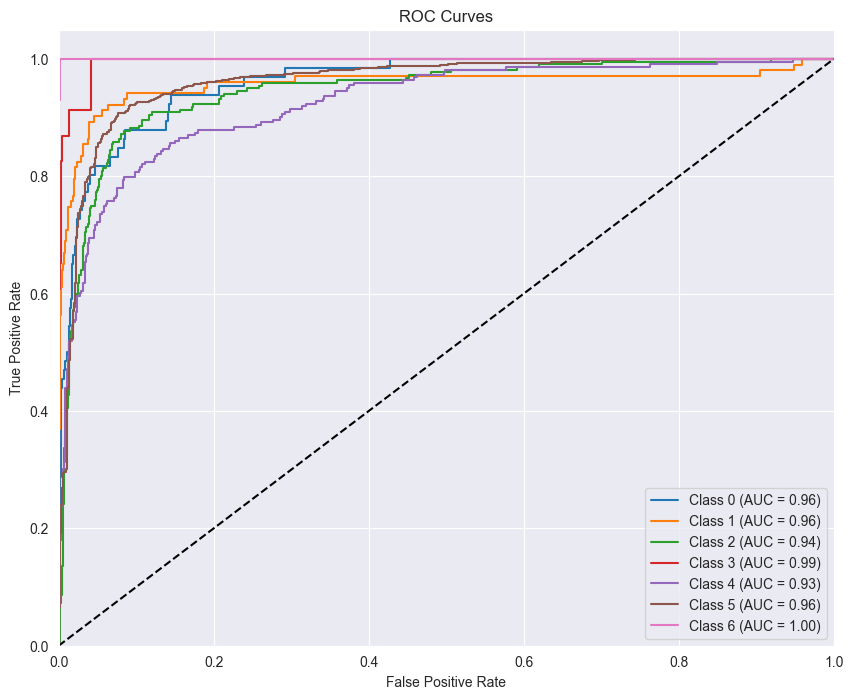

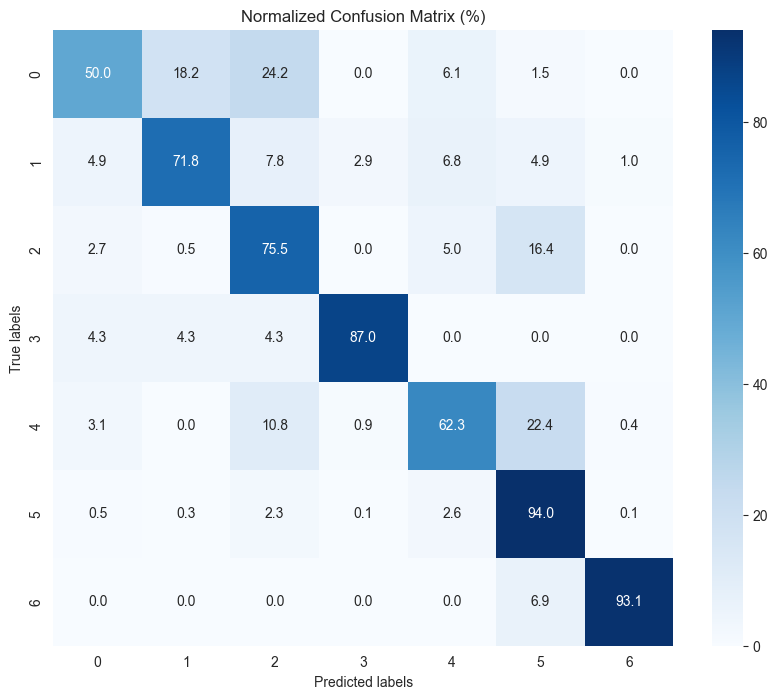

C:\Users\Park\AppData\Local\Temp\ipykernel_75228\3466997327.py:132: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  input_tensor = torch.FloatTensor(original_images[idx:idx+1]).cuda()


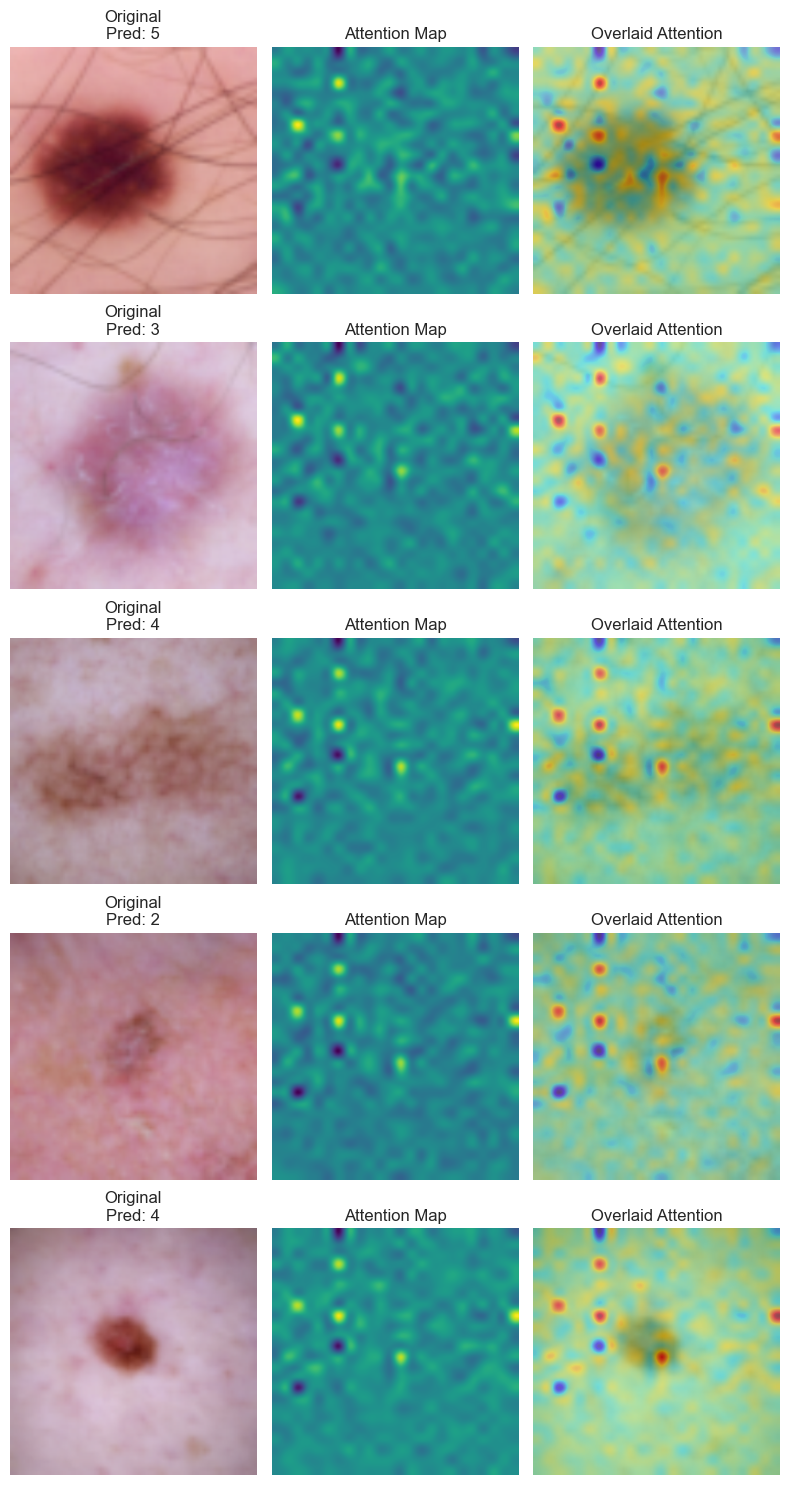

In [9]:
# Load the best model
save_path = 'Skin Disease Transformer'
checkpoint = torch.load(os.path.join(save_path, 'Vit_best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])

# Test set evaluation
model.eval()
y_true = []
y_score = []
attention_maps = []
original_images = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.cuda(), targets.cuda()

        # Get model outputs
        outputs = model(inputs)
        outputs = outputs.softmax(dim=-1)

        # Store original images and results
        original_images.extend(inputs.cpu().numpy())
        y_true.extend(targets.cpu().numpy())
        y_score.extend(outputs.cpu().numpy())

y_true = np.array(y_true)
y_score = np.array(y_score)
y_pred = np.argmax(y_score, axis=1)

# 1. Calculate performance metrics
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print(f'Accuracy: {100*accuracy:.3f}%')
print(f'Precision: {100*precision:.3f}%')
print(f'Recall: {100*recall:.3f}%')
print(f'F1-score: {100*f1:.3f}%')

# 2. Plot ROC curves
plt.figure(figsize=(10, 8))
y_true_bin = label_binarize(y_true, classes=range(n_classes))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.show()

# 3. Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Normalized Confusion Matrix (%)')
plt.show()

# 4. Visualize original images and attention maps
def get_attention_map(model, input_tensor):
    # Function to get attention maps
    model.eval()
    attention_maps = []

    def hook_fn(module, input, output):
        attention_maps.append(output.detach())

    for name, module in model.named_modules():
        if 'attn' in name and hasattr(module, 'qkv'):
            handle = module.qkv.register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(input_tensor)

    handle.remove()

    if len(attention_maps) == 0:
        raise ValueError("No attention maps were captured")

    attention = attention_maps[-1]

    try:
        n = int(np.sqrt(attention.shape[-1]))
        attention = attention.mean(dim=1)
        attention = attention.reshape(-1, n, n)
        attention = torch.nn.functional.interpolate(
            attention.unsqueeze(1),
            size=(224, 224),
            mode='bicubic',
            align_corners=False
        ).squeeze()
        return attention.cpu().numpy()
    except Exception as e:
        return None

def visualize_attention(model, original_images, predictions, num_samples=5):
    # Create a large figure with 5 rows and 3 columns
    plt.figure(figsize=(8, 15))

    for idx in range(min(num_samples, len(original_images))):
        # Process original image
        orig_img = original_images[idx].transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        orig_img = std * orig_img + mean
        orig_img = np.clip(orig_img, 0, 1)

        # Get attention map
        input_tensor = torch.FloatTensor(original_images[idx:idx+1]).cuda()
        attention_map = get_attention_map(model, input_tensor)

        if attention_map is not None:
            # Original image
            plt.subplot(5, 3, idx*3 + 1)
            plt.imshow(orig_img)
            plt.title(f'Original\nPred: {predictions[idx]}')
            plt.axis('off')

            # Attention map
            plt.subplot(5, 3, idx*3 + 2)
            plt.imshow(attention_map, cmap='viridis')
            plt.title('Attention Map')
            plt.axis('off')

            # Overlaid attention map
            plt.subplot(5, 3, idx*3 + 3)
            plt.imshow(orig_img)
            plt.imshow(attention_map, cmap='jet', alpha=0.5)
            plt.title('Overlaid Attention')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Usage
# Usage
visualize_attention(model, original_images, y_pred)